In [25]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import re
import joblib
import random
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib as mpl
from syd import make_viewer, Viewer
from tqdm import tqdm
import optuna

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer, get_placefield_location, uniq_val_filter
from vrAnalysis.processors.em import process_session
from vrAnalysis.processors.placefields import get_placefield, get_placefield_prediction, convert_position_to_bins
from vrAnalysis.processors.support import get_gauss_kernel, convolve_toeplitz, smooth
from dimensionality_manuscript.registry import PopulationRegistry
from dimensionality_manuscript import LocPredConfig
from dimensionality_manuscript import ResultsStore, ResultsAggregator

plt.rcParams["font.size"] = 18

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()
cfg = LocPredConfig()

In [2]:
isession = 41
spks_type = "oasis"
session_iterable = sessiondb.iter_sessions(imaging=True, session_params=dict(spks_type=spks_type))

# session = random.choice([s for s in session_iterable if s.mouse_name == "ATL027"])
session = session_iterable[isession]
print(session)
print(session.environments)

# results = cfg.process(session, registry)
fit = cfg.fit(session, registry)
hyperparameters = cfg.optimize(session, registry, fit)
score_null = cfg.score(session, registry, fit, hyperparameters=None)
score = cfg.score(session, registry, fit, hyperparameters=hyperparameters)

B2Session(mouse_name='ATL022', date='2023-04-18', session_id='701', spks_type='oasis')
[1 3]


In [26]:
loss_types = [re.fullmatch(r"poisson_(.+)", k).group(1) for k in score["loss_scalar"].keys() if re.fullmatch(r"poisson_(.+)", k)]
print("Loss types:")
for loss_type in loss_types:
    print(f"  {loss_type}")

print("Likelihood methods:")
print(cfg.likelihood_methods)

Loss types:
  cross_entropy
  rank_loss_logistic_mean
  rank_metric_mean_rank
  rank_metric_median_rank
  rank_metric_mrr
  rank_metric_top1
  rank_metric_top5
  rank_metric_top10
  distance_error
  env_swap
Likelihood methods:
('poisson', 'gaussian', 'diag_gaussian')


In [29]:
method_width = max(len(method) for method in cfg.likelihood_methods)

for loss_type in loss_types:
    print(loss_type)

    for likelihood_method in cfg.likelihood_methods:
        _score_null = score_null["loss_scalar"][f"{likelihood_method}_{loss_type}"]
        _score = score["loss_scalar"][f"{likelihood_method}_{loss_type}"]

        print(f"   {likelihood_method:<{method_width}} : " f"{_score_null:8.2f} -> {_score:8.2f}")

cross_entropy
   poisson       :    13.99 ->     2.78
   gaussian      :     2.93 ->     2.72
   diag_gaussian :   100.03 ->     2.56
rank_loss_logistic_mean
   poisson       :     0.39 ->     0.07
   gaussian      :     0.11 ->     0.10
   diag_gaussian :     2.62 ->     0.06
rank_metric_mean_rank
   poisson       :     5.48 ->     5.48
   gaussian      :     8.08 ->     8.08
   diag_gaussian :     5.74 ->     5.74
rank_metric_median_rank
   poisson       :     3.00 ->     3.00
   gaussian      :     4.00 ->     4.00
   diag_gaussian :     3.00 ->     3.00
rank_metric_mrr
   poisson       :     0.41 ->     0.41
   gaussian      :     0.39 ->     0.39
   diag_gaussian :     0.42 ->     0.42
rank_metric_top1
   poisson       :     0.20 ->     0.20
   gaussian      :     0.17 ->     0.17
   diag_gaussian :     0.20 ->     0.20
rank_metric_top5
   poisson       :     0.71 ->     0.71
   gaussian      :     0.68 ->     0.68
   diag_gaussian :     0.74 ->     0.74
rank_metric_top10
   poiss

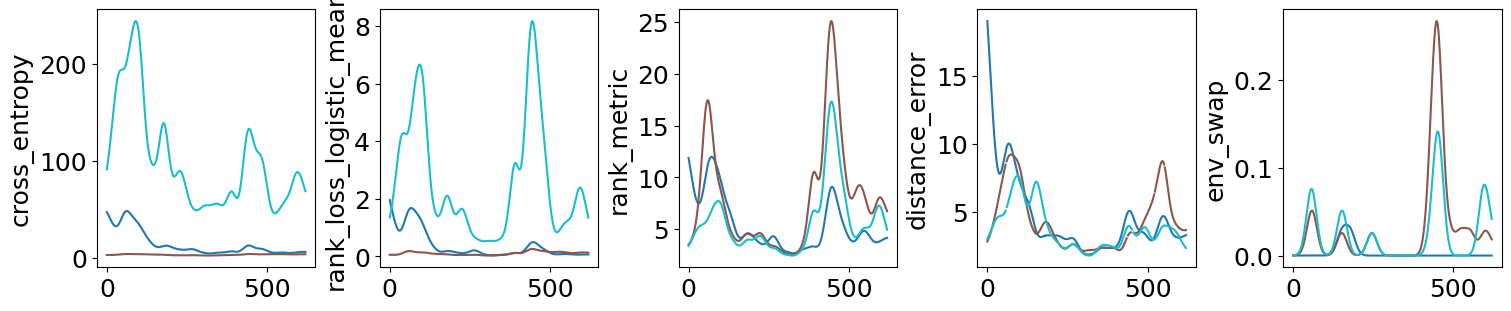

In [10]:
# Get m
num_loss = len(cfg.loss_methods)
num_ll = len(cfg.likelihood_methods)
colors = plt.colormaps["tab10"](np.linspace(0, 1, num_ll))

plt.close("all")
fig, ax = plt.subplots(1, num_loss, figsize=(3 * num_loss, 3), layout="constrained")
for iloss, loss_method in enumerate(cfg.loss_methods):
    for ill, ll_method in enumerate(cfg.likelihood_methods):
        ckey = f"{ll_method}_{loss_method}"
        cval = results["loss_trajectory"][ckey]
        xx = np.arange(len(cval))
        fval = smooth(cval, xx, 11)
        ax[iloss].plot(fval, color=colors[ill], label=ll_method)
    ax[iloss].set_ylabel(loss_method)
    # ax[iloss].legend()
plt.show()

In [11]:
results["loss_scalar"]

{'poisson_cross_entropy': 13.992315292358398,
 'poisson_rank_loss_logistic_mean': 0.3925209641456604,
 'poisson_rank_metric_mean_rank': 5.48792270531401,
 'poisson_rank_metric_median_rank': 3.0,
 'poisson_rank_metric_mrr': 0.407351394238442,
 'poisson_rank_metric_top1': 0.19484702093397746,
 'poisson_rank_metric_top5': 0.7053140096618358,
 'poisson_rank_metric_top10': 0.8792270531400966,
 'poisson_distance_error': 4.578352180936995,
 'poisson_env_swap': 0.00322061191626409,
 'gaussian_cross_entropy': 2.9341986179351807,
 'gaussian_rank_loss_logistic_mean': 0.1113625019788742,
 'gaussian_rank_metric_mean_rank': 8.075684380032206,
 'gaussian_rank_metric_median_rank': 4.0,
 'gaussian_rank_metric_mrr': 0.38746878615627345,
 'gaussian_rank_metric_top1': 0.1723027375201288,
 'gaussian_rank_metric_top5': 0.679549114331723,
 'gaussian_rank_metric_top10': 0.8711755233494364,
 'gaussian_distance_error': 4.302828618968386,
 'gaussian_env_swap': 0.0322061191626409,
 'diag_gaussian_cross_entropy': 